<a href="https://colab.research.google.com/github/joshuajhchoi/ai2learn/blob/master/eda_to_prediction_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

타이타닉 EDA to Prediction

* 타이타닉 챌린지는 나이, 성별 또는 승객 클래스와 같은 변수를 기반으로 주어진 승객의 생존 또는 사망을 예측하는 경쟁입니다.



##목차

#### Part1: Exploratory Data Analysis(EDA):
* 내용 분석​
* 여러 기능을 고려한 관계 또는 경향 찾기

#### Part2: Feature Engineering and Data Cleaning:
* 몇 가지 항목 추가
* 중복 항목 제거
* 모델링에 적합한 형상으로 항목 변환

#### Part3: Predictive Modeling
* 기본 알고리즘 실행
* 교차 검증
* 앙상블
* 중요 항목 추출


Part1: Exploratory Data Analysis(EDA)

* 자료 다운로드하기
[자료 다운로드](https://www.kaggle.com/c/3136/download-all)

으로 가서 파일을 다운로드 한다. (Kaggle note에서 할 때는 불러 오는 것이 좀 더 단순하나 주피터 노트북에서 할 때는 다운로드 및 임포트를 해야한다.)

* 필요한 것들을 임포트 좀 해야겠죠.

* math, time, random, datetime 등의 모듈을 임포트합니다.


In [ ]:
import math, time, random, datetime

* 다음에는 데이터를 처리할 라이브러리를 임포트합니다.

In [ ]:
import numpy as np
import pandas as pd

* 그 다음은 비쥬얼라이제이션을 할 것을 import 합니다.

In [ ]:
import matplotlib.pyplot as plt
import missingno
import seaborn as sns
plt.style.use('seaborn-whitegrid')

* matplolib의 pyplot은 이미 익숙하실 것이다.
* missingno 패키지는 누락데이터에 대한 시각화를 쉽게 할 수 있다. matrix()명령은 매트리스 형태로 누락데이터를 시각화하는 명령이다. 즉, 몽땅 까맣게 나오면 해당 열의 데이터가 다 있다는 이야기이고, 중간에 흰 것들이 나오면 이는 빈칸이 많다는 것을 보여준다.
* plt.style.use('seaborn-whitegrid')은 matplotlib에서 seaborn whitegrid 모양의 플롯을 쓰겠다는 것이다. 자체적 뿐만 아니라 R에서 널리 사용되는 ggplot 같은 것도 사용할 수 있다.
* 아래 %matplotlib inline의 역할은 주피터 노트북을 실행한 브라우저에서 바로 그림을 볼 수 있게 해주는 역할을 합니다. 이 라인을 넣지 않으면 그래프 등을 못 보실 수 도 있습니다.

In [ ]:
%matplotlib inline

* 자 이제는 프리 프로세싱을 하는 모듈 들을 sklearn에서 불러온다

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, label_binarize

* OneHotEncoder는 범주형 변수를 바이너리화 하는 모듈이다.
* Label Encoder는 문자형 라벨을 정수형으로 바꾸어 주는 모듈이다.
* labelbinarize는 라벨을 바이너리로 바꾸어 주는 모듈이다.

* 이어서 머신러닝하는 알고리즘을 불러온다.
* 하나만 사용하는 것이 아니라 아주 여러 가지를 경험해 본다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import model_selection, tree, preprocessing, metrics, linear_model
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier

* 마지막으로 warning 안 나오게

In [ ]:
import warnings
warnings.filterwarnings('ignore')

####파일보기

* 파일을 보겠습니다.

* 우측의 Data에 가셔서 input 에서 원하는 파일을 보세요

In [ ]:
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')
gender_submission = pd.read_csv('../input/gender_submission.csv')

* 우리가 기계를 훈련시킬 트레인 파일을 한 번 보도록 하겠습니다.

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


* 우리가 나중에 최종 시험 볼 대상인 test 파일을 보겠습니다.

In [ ]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


* 마지막으로 우리가 제출할 포맷이 될 gender submission 파일을 보겠습니다.

In [ ]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


* 보시다시피 Passenger id 는 단지 누구가 누구이다 라는 것을 밝히는 identifier인 것 같고
* Survived 는 0이면 사망이고 1이면 살아 남은 사람인 것 같습니다.
* 그럼 일단 훈련시킬 train 파일에 집중하도록 하겠습니다.
* 파일의 크기를 보지요

In [ ]:
len(train)

891

* 891명에 대한 데이터 입니다.

####최초 분석
https://www.kaggle.com/c/titanic/data
* 위의 링크에 가면 데이터 항목의 딕쇼너리를 보실 수 있습니다.

* 항목을 보면 PClass 는 객실의 레벨인 것 같습니다. 1이 제일 좋은 곳이고 3이 제일 낮은 곳인 것 같습니다.
* 이름은 별 의미가 없을 수도 있으나 중간에 Mr. Miss, Mrs 등이 아닌 master, rev, capt 등이 나옵니다.
* Sex는 중요합니다. 보나마나 여성과 아이들을 우선적으로 구명 보트에 타게 했을 것이므로 남성이면 사망 확률이 훨씬 높지요
* Age도 중요합니다. 어릴 수록 구명 보트에 탔을 가능성이 크니까요
* SibSp는 배우자나 형제들과 같이 탄 즉, 가족의 숫자를 나타내므로 가족이 있는 사람의 생존 확률은 컸을 것이라 사료 됩니다.
* Parch 는 부모, 아이들이 같이 탄 경우니까, 역시 생존 확률이 좀 더 높을 것이라 생각됩니다.
* Ticket은 어떻게 의미를 두어야 할지 아직 파악이 안 됩니다.
* Fare는 비쌀 수록 생존 확률이 높을 가능성이 큽니다.
* Cabin도 정해진 캐빈에서의 생존률이 더 높을 수 있습니다. NaN은 Not a number란 뜻인데 아마도 크루이었거나 정확한 방 배정이 안 된 단체로 자는 사람들이 아니었나는 생각이 들기도 합니다.
* Embarked는 어디서 탔냐는 이야기인데, 관계가 있을 수는 있어도 큰 요인은 아닐 것이라는 것이 추측입니다.

#### 최초 추측

저는 가장 중요한 요소 10가지를 구분해보았습니다.
1. 당시의 사회적 분위기로 여성과 아이를 우선하는 젠틀맨쉽에 따라 여성이면 우선적으로 구명 보트에 탈 수 있었을 것입니다.
2. 1번의 조건에 따라 역시 아이들의 경우에 구명보트에 탈 수 있는 확률이 높았을 거이라 생각됩니다.
3. P Classs는 좌석 등급이므로 1등석이 2등석보다 2등석은 3등석보다 구명보트를 탈 수 있는 확률이 높았을 것이라 생각됩니다.
4. 3번의 조건에 따라 가격이 높을 수록 구명 보트에 탈 확률은 높았을 것이다.

위 4개가 가장 결정적인 것이고, 아래 4개는 상대적으로 연관성이 좀 적은 것입니다.
5. 우선은 캐빈의 위치인데 A가 제일 높고 리스트에 없는 것이 제일 낮았을 것이다.
6. 배우자가 있고 없고는 영향을 준다.
7. 아이가 하나 있는 사람은 없는 사람보다 나으나 너무 많은 사람은 오히려 생존에 불리했을 수도 있다.
8. 숫자는 적으나 이름에 master가 붙은 사람은 아이들로 생존확률이 높고, Dr나 Sir도 생존확률이 높다고 보인다. 반면에 목사님들인 Rev이나 군인을 나타내는 Captain, capt, major 등의 계급이 있는 사람은 스스로 희생했을 가능성이 크다.

그리고 가장 영향이 적은 것은
9.  배를 탄 장소는 아주 약간의 영향을 미친다
10. 티켓 번호는 아주 적은 영향만을 미친다

* 이제 하나씩 훓어 보며 작업을 해보겠습니다.

* 우리의 목표는 train에서 모델을 뽑아서 test에서 누가 살아 남았을 확률이 큰가를 뽑아 내는 것입니다.

In [ ]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### 빠진 데이터를 보겠습니다.

* 이는 중요합니다.
* 예를 들어 나이가 빠져 있으면 사망자일 확률이 높을 수도 있고 등 등
* 무엇보다 데이터가 없으면 분석을 할 수가 없겠지요?

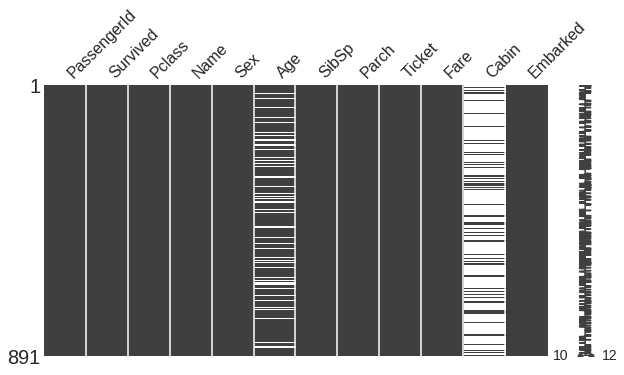

In [ ]:
missingno.matrix(train, figsize = (10,5))

* 보시다시피 나이와 캐빈 번호에서 구멍이 많습니다.
* 빈칸의 숫자를 보겠습니다.

In [ ]:
train.isnull().sum() #비어 있는 값들을 체크해 본다.

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

* Age는 177개가 없고, Cabin 687개가 없습니다. 그리고 Embarked에도 2개의 빈 데이터가 있습니다.
* 머신러닝 툴은 빈칸을 아주 싫어 합니다.
* 나중에 이를 어떻게 할 것인지 좀 생각해 보겠습니다.

* 이제 데이터 분석을 위해 새로운 데이터프레임 2개를 만들어 봅니다.

In [ ]:
df_bin = pd.DataFrame()
df_con = pd.DataFrame()

* 각 열의 데이터 타입을 보겠습니다.

In [ ]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

* 자 한열씩 검토해 보겠습니다.

## 항목의 종류

### 범주형 항목 :
범주형 변수는 둘 이상의 결과 요소가 있는 변수이며 해당 기능의 각 값을 범주별로 분류 할 수 있습니다. 예를 들어 성별은 두 가지 범주 (남성과 여성)의 범주 형 변수입니다. ** 이산형 변수(discrete variable) = 범주형 변수 (categorical variable) 의 하나로 명목 변수 norminal variable **라고도합니다.

** 데이터 셋에서 명목 항목 : Sex, Embark ** 이며 우리는 Name, Ticket 등을 이로 변환해야 할 것 같습니다.

Ordinal Variable :
순위 변수는 범주 형의 하나지만 그 차이점은 값 사이의 상대 순서(=서열) 또는 정렬이 가능하다는 것입니다. 예를 들어 값이 ** Tall, Medium, Short ** 인 ** Height **와 같은 피처가있는 경우 Height는 서수 변수입니다. 여기서 변수에 상대적인 정렬을 할 수 있습니다.

** 데이터 셋에서 순위 항목 : PClass ** 이며 우리는 Cabin을 이 범주로 변환해서 사용해야 할 것 같습니다.

### 연속형 항목 :
서로 연속된 값을 가진 변수를 가진 항목이며 여기에서 우리는 연령을 대표적인 것으로 볼 수 있습니다.

** 데이터 셋에서 순위 항목 : Age ** 이며, Age, SipSp, Parch, Fare는 interval variable로 만들어 이에 적용해야 할 것 같습니다.

####1. Survived

(0 - Not Survived, 1- Survived)

0    549
1    342
Name: Survived, dtype: int64


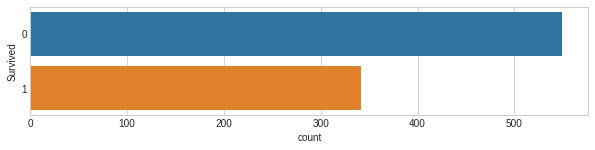

In [ ]:
fig = plt.figure(figsize=(10,2))
sns.countplot(y='Survived', data=train)
print(train.Survived.value_counts())

* 불행히도 사망자가 훨씬 많아 보입니다.
* 전체 사망자 비율을 좀 보겠습니다.

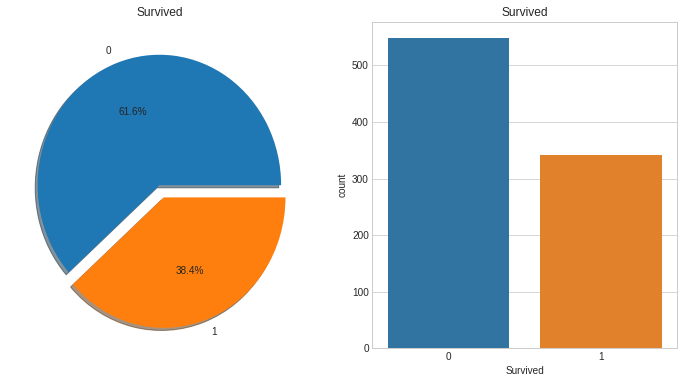

In [ ]:
f,ax=plt.subplots(1,2,figsize=(12,6))
train['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('Survived')
ax[0].set_ylabel('')
sns.countplot('Survived',data=train,ax=ax[1])
ax[1].set_title('Survived')
plt.show()

* 이제 생존한 사람들의 데이터를 우리가 만든 새로운 데이터 프레임에 옮겨 놓습니다.

In [ ]:
df_bin['Survived'] = train['Survived']
df_con['Survived'] = train['Survived']

* 잘 들어 갔나 확인해 봅니다.

In [ ]:
df_bin.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
df_con.head()

,Survived
0,0
1,1
2,1
3,1
4,0


#### 2. Pclass

1 = 1st, 2= 2nd, 3 = 3rd

* 각 클래스 당 생존자를 보겠습니다.

In [ ]:
train.groupby(['Pclass','Survived'])['Survived'].count()

Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
Name: Survived, dtype: int64

In [ ]:
pd.crosstab(train.Pclass,train.Survived,margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


* 1등급 객실의 사람들은 생존자가 더 많고, 2등급은 생존자에 비해 사망자가 조금 더 많으나, 3등급은 사망자가 3배 이상 많다는 것을 알 수 있습니다.

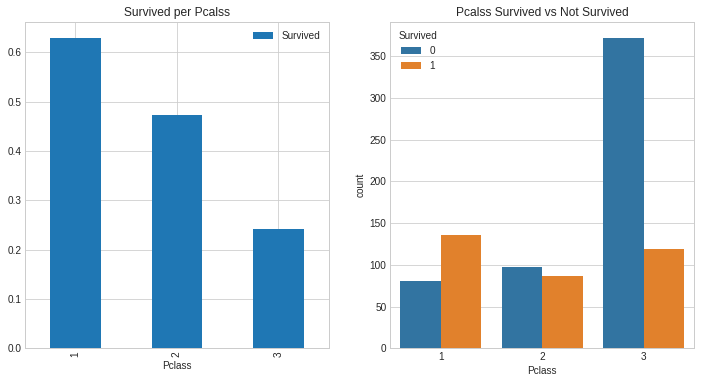

In [ ]:
f,ax=plt.subplots(1,2,figsize=(12,6))
train[['Pclass','Survived']].groupby(['Pclass']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived per Pcalss')
sns.countplot('Pclass',hue='Survived',data=train,ax=ax[1])
ax[1].set_title('Pcalss Survived vs Not Survived')
plt.show()

* 이제 이를 다시 우리 데이터 프레임에 넣습니다.

In [ ]:
df_bin['Pclass'] = train['Pclass']
df_con['Pclass'] = train['Pclass']

In [ ]:
df_bin.head()

,Survived,Pclass
0,0,3
1,1,1
2,1,3
3,1,1
4,0,3


In [ ]:
df_con.head()

,Survived,Pclass
0,0,3
1,1,1
2,1,3
3,1,1
4,0,3


#### 3. Name

* 이름은 거의 모두 다를 가능성이 큽니다. Family Name, First Name, Middle Name and even Dr. Capt, master and so on 모두 감안하면...
* 분류를 한 번 해 봅니다.
* 리스트를 한 번 주 욱 보겠습니다.

In [ ]:
train.Name.value_counts()

Rice, Master. Eugene                              1
Alhomaki, Mr. Ilmari Rudolf                       1
Saalfeld, Mr. Adolphe                             1
Moor, Mrs. (Beila)                                1
Van Impe, Mr. Jean Baptiste                       1
Cann, Mr. Ernest Charles                          1
Barbara, Mrs. (Catherine David)                   1
Moussa, Mrs. (Mantoura Boulos)                    1
Seward, Mr. Frederic Kimber                       1
Shelley, Mrs. William (Imanita Parrish Hall)      1
Wilhelms, Mr. Charles                             1
Allison, Master. Hudson Trevor                    1
Abbott, Mr. Rossmore Edward                       1
Nasser, Mr. Nicholas                              1
Culumovic, Mr. Jeso                               1
Crosby, Capt. Edward Gifford                      1
Hendekovic, Mr. Ignjac                            1
Palsson, Master. Gosta Leonard                    1
Hays, Miss. Margaret Bechstein                    1
Dahl, Mr. Ka

* 이름에서 Mr. Mrs. Dr. Rev.등을 찾아 보겠습니다.
* 여기서는 Regex [A-Za-z]+)를 사용하는데 이는 A-Z 까지 또는 a-z까지에서 마침표가 따라오는 것을 찾습니다.
* Iniital이란 열을 만들어 이를 입력합니다.

In [ ]:
train['Initial']=0
for i in train:
    train['Initial']=train.Name.str.extract('([A-Za-z]+)\.')

* 이를 성별로 봅니다.

In [ ]:
pd.crosstab(train.Initial,train.Sex).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


* Mlle, Mme, Don, Jonkheer 등은 오탈자일 가능성이 큰데 바꾸어 봅니다.
* Countess, Lady와 Sir는 Nbl(Noble)로 바꾸고
* 'Major','Col', 'Capt'는 Sol(Soldier)로 바꾸겠습니다.
           data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Dr','Sol','Nbl','Nbl','Mr','Sol','Rev','Sol','Nbl','Mr'],inplace=True)

In [ ]:
train['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],['Miss','Miss','Miss','Dr','Sol','Nbl','Nbl','Mr','Sol','Rev','Sol','Nbl','Mr'],inplace=True)

*file을 한 번 보겠습니다.

In [ ]:
train.Initial.value_counts()

Mr        519
Miss      186
Mrs       125
Master     40
Dr          7
Rev         6
Sol         5
Nbl         3
Name: Initial, dtype: int64

* 이제 이를 밸류 값으로 바꾸어 봅니다.

         Mr        1
         Miss      2
         Mrs       3
         Master    4
         Dr        5
         Rev       6
         Sol       7
         Nbl       8


In [ ]:
train['Initial'].replace(['Mr','Miss','Mrs','Master','Dr','Rev','Sol', 'Nbl'],[1,2,3,4,5,6,7,8],inplace=True)

* 다시 한번 파일을 보겠습니다.

In [ ]:
train.Initial.value_counts()

1    519
2    186
3    125
4     40
5      7
6      6
7      5
8      3
Name: Initial, dtype: int64

* 이제 이를 새 파일로 다시 옮깁니다.

In [ ]:
df_bin['Name'] = train['Initial']
df_con['Name'] = train['Initial']

* 확인해 봅니다.

In [ ]:
df_bin.head()

,Survived,Pclass,Name
0,0,3,1
1,1,1,3
2,1,3,2
3,1,1,3
4,0,3,1


In [ ]:
df_con.head()

,Survived,Pclass,Name
0,0,3,1
1,1,1,3
2,1,3,2
3,1,1,3
4,0,3,1


#### 4. Sex

In [ ]:
train.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

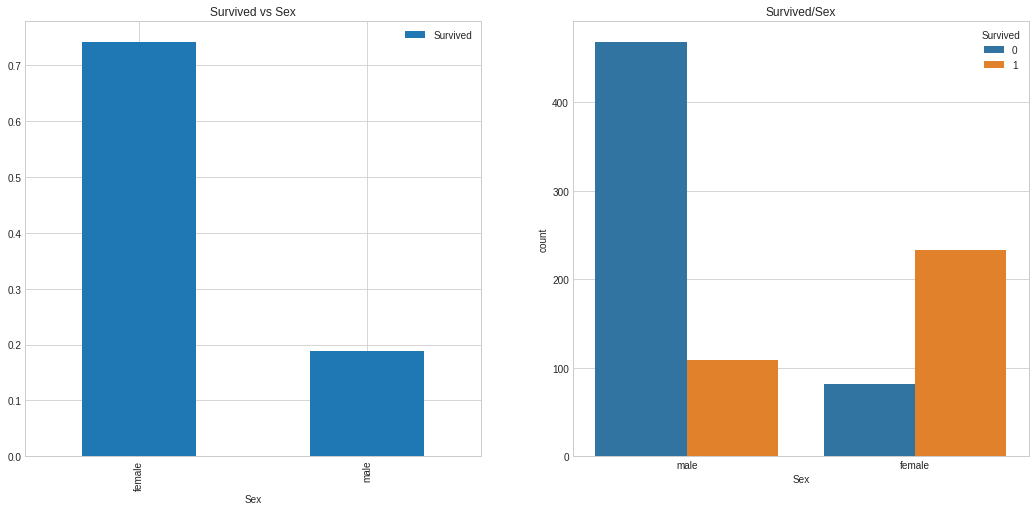

In [ ]:
f,ax=plt.subplots(1,2,figsize=(18,8))
train[['Sex','Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survived vs Sex')
sns.countplot('Sex',hue='Survived',data=train,ax=ax[1])
ax[1].set_title('Survived/Sex')
plt.show()

* 배에 있던 남자의 수는 여자의 수보다 훨씬 많습니다. 여전히 생존 여성 수는 남성 수의 거의 두 배입니다. ** 선박 여성의 생존율은 약 75 % 인 반면 남성의 생존율은 약 18-19 %입니다. **

In [ ]:
pd.crosstab([train.Sex,train.Survived],train.Pclass,margins=True).style.background_gradient(cmap='summer_r')

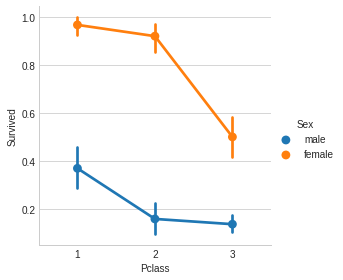

In [ ]:
sns.factorplot('Pclass','Survived',hue='Sex',data=train)
plt.show()

이 경우 ** FactorPlot **을 사용합니다. 범주형 값을 쉽게 분리 할 수 있기 때문입니다.

** CrossTab ** 및 ** FactorPlot **을 보면 Pclass1에서 온 ** 여성의 생존률이 ** 95-96 % **임을 쉽게 유추 할 수 있습니다. (불과 3명/94명 사망).

Pclass와 상관없이 구출하는 동안 여성에게 최우선 순위가 부여 된 것은 분명합니다. Pclass1의 남성조차도 생존율이 매우 낮습니다.

* 성별을 남자 1, 여자2로 바꾼 후 새로운 파일로 옮깁니다.

In [ ]:
train['Sex'].replace(['male','female'],[1,2],inplace=True)

In [ ]:
df_bin['Sex'] = train['Sex']
df_con['Sex'] = train['Sex']

In [ ]:
df_bin.head()

,Survived,Pclass,Name,Sex
0,0,3,1,1
1,1,1,3,2
2,1,3,2,2
3,1,1,3,2
4,0,3,1,1


In [ ]:
df_con.head()

,Survived,Pclass,Name,Sex
0,0,3,1,1
1,1,1,3,2
2,1,3,2,2
3,1,1,3,2
4,0,3,1,1


#### 5. Age


In [ ]:
print('Oldest Passenger was of',train['Age'].max(),'Years')
print('Youngest Passenger was of',train['Age'].min(),'Years')
print('Average Age on the ship',int(train['Age'].mean()),'Years')

Oldest Passenger was of 80.0 Years
Youngest Passenger was of 0.42 Years
Average Age on the ship 29 Years


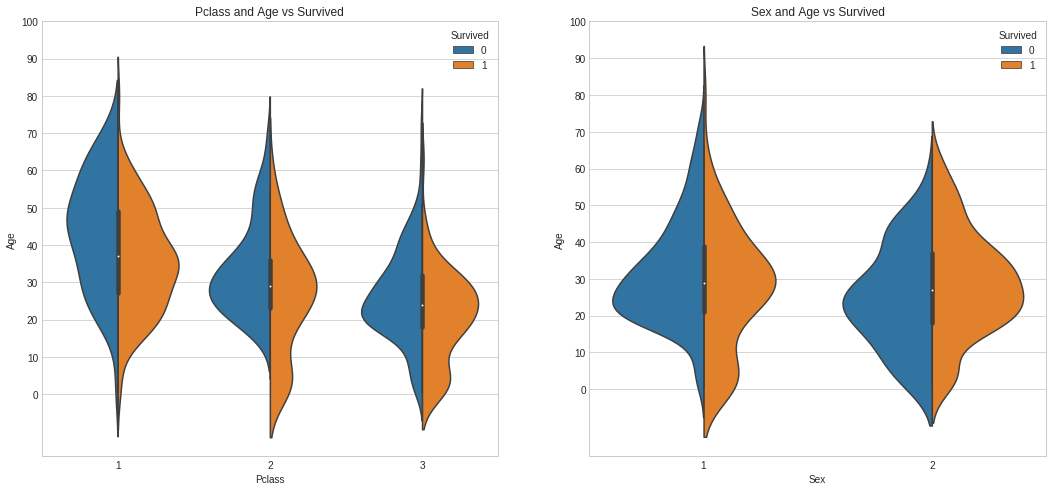

In [ ]:
f,ax=plt.subplots(1,2,figsize=(18,8))
sns.violinplot("Pclass","Age", hue="Survived", data=train,split=True,ax=ax[0])
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0,110,10))
sns.violinplot("Sex","Age", hue="Survived", data=train,split=True,ax=ax[1])
ax[1].set_title('Sex and Age vs Survived')
ax[1].set_yticks(range(0,110,10))
plt.show()

#### 관찰 :

1) Pclass에 따라 어린이 수가 증가하고 10 세 미만의 어린이 (즉, 어린이)의 생존율은 Pclass에 상관없이 양호해 보입니다.

2) Pclass1에서 20-50세의 Passeneger의 생존 가능성은 높고 여성에게는 더 좋습니다.

3) 남성의 경우 생존 확률은 나이가 증가함에 따라 감소합니다.

* 앞에서 살펴본 것처럼 Age 항목에는 ** 177 ** null 값이 있습니다. 이러한 NaN 값을 대체하기 위해 데이터 집합의 평균 수명을 지정할 수 있습니다.

* 그러나 문제는 평균 연령이 29 세를 4세 아이에게 할당 할 수 없습니다. 승객이 어떤 연령대에 있는지 알 수있는 방법이 있을까요? 나이에서 힌트를 찾아 봅니다.

* Initial 별 평균 연령을 보고 적용 시키는 것이 좋을 것 같습니다.

In [ ]:
train.groupby('Initial')['Age'].mean() #이니셜 별 평균 연령 체크

Initial
1    32.401250
2    21.860000
3    35.898148
4     4.574167
5    42.000000
6    43.166667
7    56.600000
8    43.333333
Name: Age, dtype: float64

* 그럼 이제 에이지 빈칸에 이니셜 별로 평균 연령을 넣겠습니다. 반올림 하겠습니다.

In [ ]:
train.loc[(train.Age.isnull())&(train.Initial==1),'Age']=32
train.loc[(train.Age.isnull())&(train.Initial==2),'Age']=22
train.loc[(train.Age.isnull())&(train.Initial==3),'Age']=36
train.loc[(train.Age.isnull())&(train.Initial==4),'Age']=5
train.loc[(train.Age.isnull())&(train.Initial==5),'Age']=42
train.loc[(train.Age.isnull())&(train.Initial==6),'Age']=43
train.loc[(train.Age.isnull())&(train.Initial==7),'Age']=57
train.loc[(train.Age.isnull())&(train.Initial==8),'Age']=43

In [ ]:
train.head(n=891)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1,3,"Heikkinen, Miss. Laina",2,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,35.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,1
5,6,0,3,"Moran, Mr. James",1,32.0,0,0,330877,8.4583,NaN,Q,1
6,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E46,S,1
7,8,0,3,"Palsson, Master. Gosta Leonard",1,2.0,3,1,349909,21.0750,NaN,S,4
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",2,27.0,0,2,347742,11.1333,NaN,S,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",2,14.0,1,0,237736,30.0708,NaN,C,3


* 혹시 나이에 빈칸이 있는지 봅니다.

In [ ]:
train.Age.isnull().any()

False

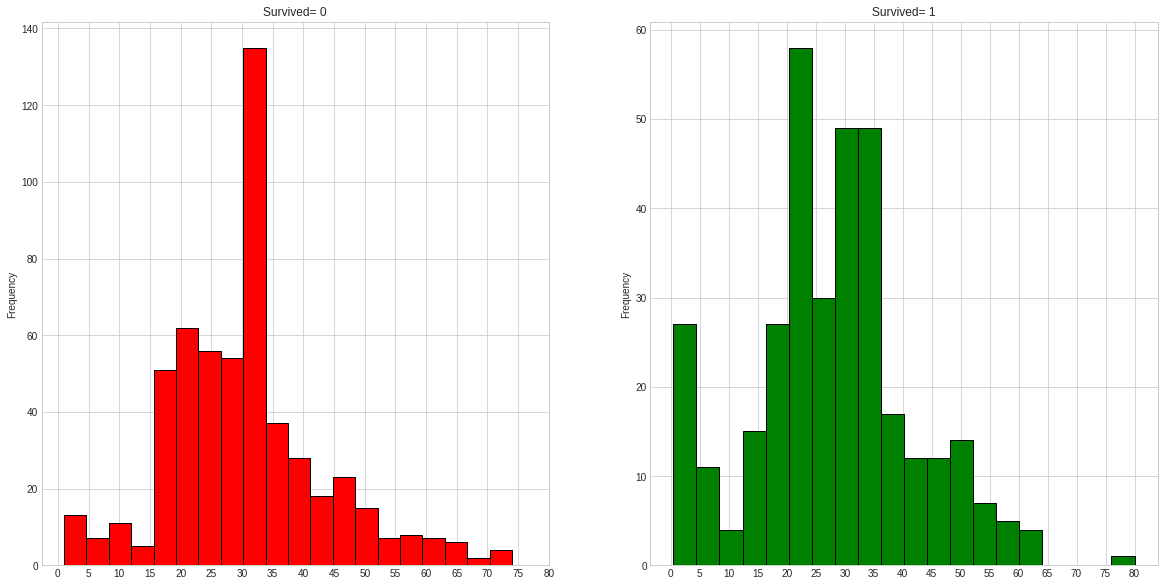

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,10))
train[train['Survived']==0].Age.plot.hist(ax=ax[0],bins=20,edgecolor='black',color='red')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)
train[train['Survived']==1].Age.plot.hist(ax=ax[1],color='green',bins=20,edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)
plt.show()

* 관측

1) 유아 (5 세 미만)는 (여성과 아동 우선 정책)으로 우선적으로 구명보트를 탈 수 있었다.

2) 가장 나이든 분은 살았으며

3) 최대사망자 그룹은 30-40 세의 연령 그룹에 있었습니다.

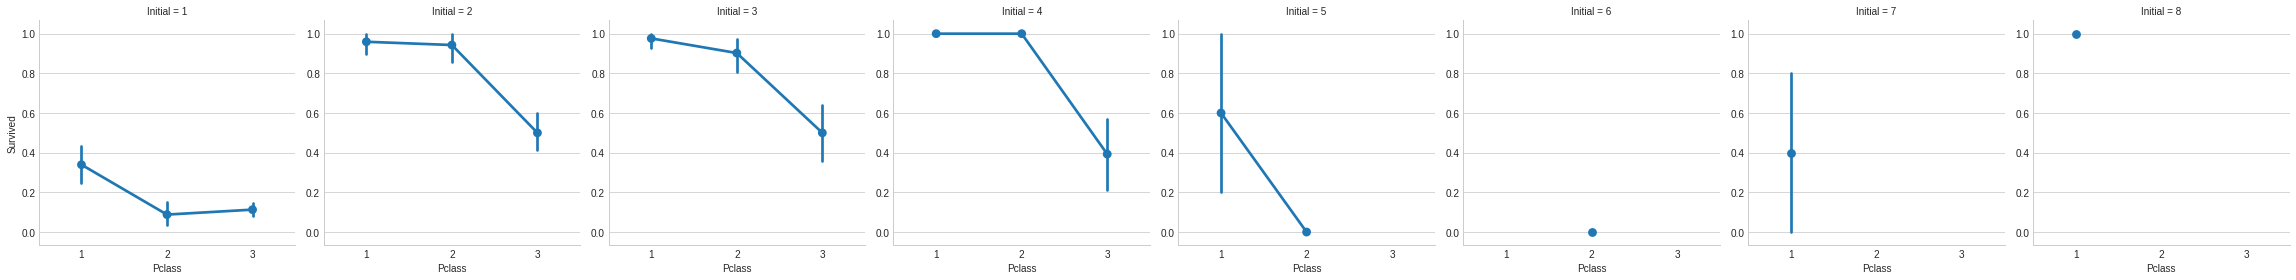

In [ ]:
sns.factorplot('Pclass','Survived',col='Initial',data=train)
plt.show()

* 자, 이제 새 파일로 옮겨 봅니다.

In [ ]:
df_bin['Age'] = train['Age']
df_con['Age'] = train['Age']

In [ ]:
df_bin.head()

,Survived,Pclass,Name,Sex,Age
0,0,3,1,1,22.0
1,1,1,3,2,38.0
2,1,3,2,2,26.0
3,1,1,3,2,35.0
4,0,3,1,1,35.0


In [ ]:
df_con.head()

,Survived,Pclass,Name,Sex,Age
0,0,3,1,1,22.0
1,1,1,3,2,38.0
2,1,3,2,2,26.0
3,1,1,3,2,35.0
4,0,3,1,1,35.0


#### 6. SibSip

* 이 항목은 탑승자가 혼자인지 또는 가족과 함께 있는지를 나타냅니다.

*Sibling = 형제, 자매, 의붓 형제, 이복 누이

Spouse = 남편, 아내

In [ ]:
pd.crosstab([train.SibSp],train.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


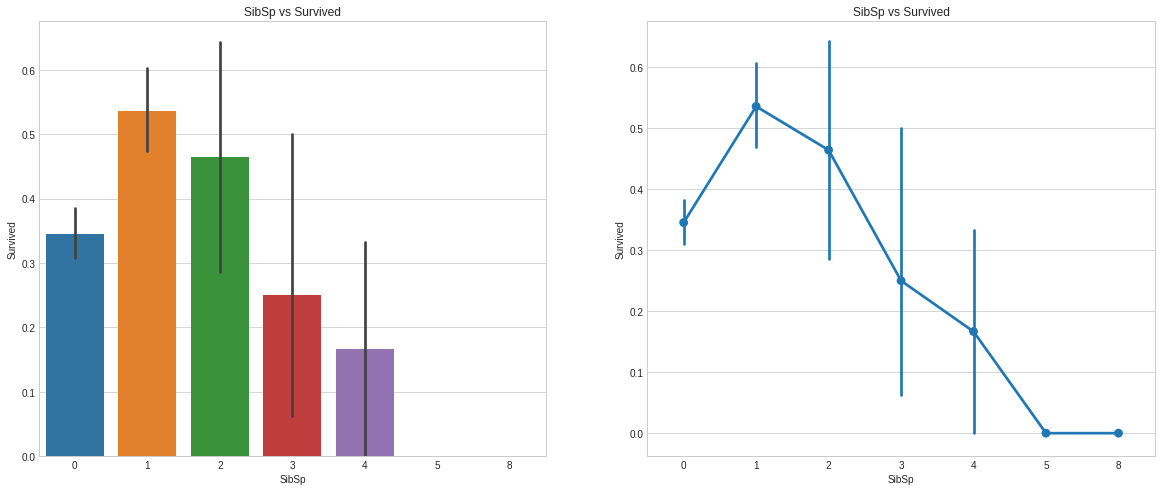

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.barplot('SibSp','Survived',data=train,ax=ax[0])
ax[0].set_title('SibSp vs Survived')
sns.factorplot('SibSp','Survived',data=train,ax=ax[1])
ax[1].set_title('SibSp vs Survived')
plt.close(2)
plt.show()

In [ ]:
pd.crosstab(train.SibSp,train.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


* 관찰 :

승객이없는 형제 자매 혼자 탄 경우, barplot 및 factorplot 쇼는 것을, 그는 34.5 %의 생존율로 평균과 비슷합니다.
하지만 저의 최초 추측과는 달리 형제 수가 증가하면 그래프가 감소합니다. 즉, 배에 가족이 남아 있으면 먼저 탈출하지 못 하고 가족을 구하려고 노력할 것입니다. 놀랍게도 5-8인 가족의 생존율은 ** 0 % **입니다.

그 이유는 ** Pclass **입니다. 크로스 탭은 SibSp> 3 인 Person이 모두 Pclass3에 있음을 보여줍니다. Pclass3 (> 3)즉, 저소득 층 대가족은 모두 사망했다는 것입니다.

* 추후 좀 변경하기로 하고 일단 새 파일에 옮겨 놓습니다.

In [ ]:
df_bin['SibSp'] = train['SibSp']
df_con['SibSp'] = train['SibSp']

In [ ]:
df_bin.head()

,Survived,Pclass,Name,Sex,Age,SibSp
0,0,3,1,1,22.0,1
1,1,1,3,2,38.0,1
2,1,3,2,2,26.0,0
3,1,1,3,2,35.0,1
4,0,3,1,1,35.0,0


In [ ]:
df_con.head()

,Survived,Pclass,Name,Sex,Age,SibSp
0,0,3,1,1,22.0,1
1,1,1,3,2,38.0,1
2,1,3,2,2,26.0,0
3,1,1,3,2,35.0,1
4,0,3,1,1,35.0,0


#### 7. Parch

In [ ]:
pd.crosstab(train.Parch,train.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


* 크로스 탭은 다시 식구 많은 쪽은 Pclass3에 있음을 보여줍니다.

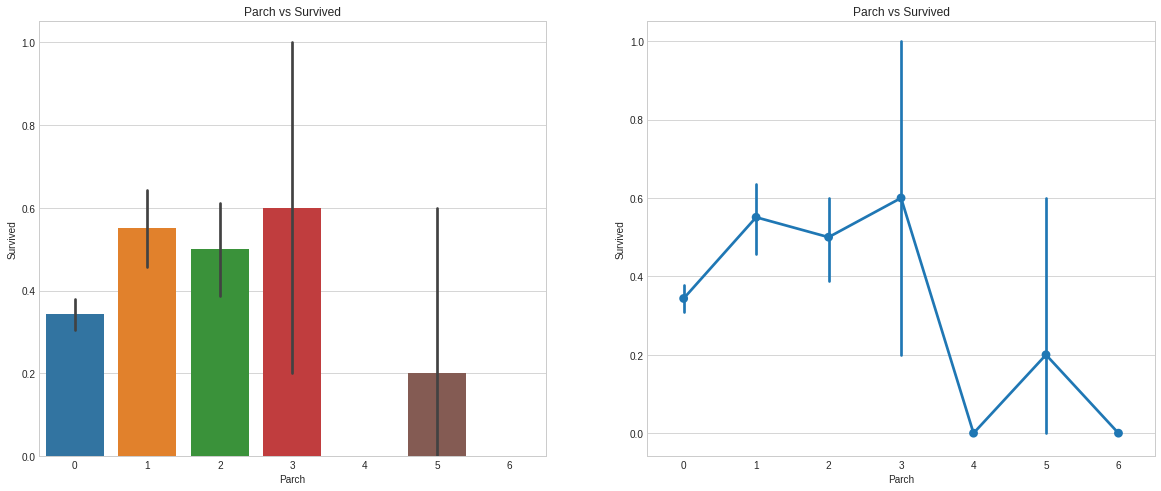

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.barplot('Parch','Survived',data=train,ax=ax[0])
ax[0].set_title('Parch vs Survived')
sns.factorplot('Parch','Survived',data=train,ax=ax[1])
ax[1].set_title('Parch vs Survived')
plt.close(2)
plt.show()

* 관찰 :

* 여기에서도 결과는 매우 비슷합니다. 부모와 함께 탑승 한 승객은 생존 가능성이 더 높습니다. 그러나 숫자가 올라 갈수록 줄어 듭니다.

* 생존 가능성은 배에 1-3 명의 부모가있는 누군가에게 좋습니다. 혼자 사는 것이 또한 치명적인 것으로 판명되고 누군가가 배에> 4 명의 부모가 있으면 생존 가능성이 줄어 듭니다.

* 추후 좀 변경하기로 하고 일단 새 파일에 옮겨 놓습니다.

In [ ]:
df_bin['Parch'] = train['Parch']
df_con['Parch'] = train['Parch']

In [ ]:
df_bin.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch
0,0,3,1,1,22.0,1,0
1,1,1,3,2,38.0,1,0
2,1,3,2,2,26.0,0,0
3,1,1,3,2,35.0,1,0
4,0,3,1,1,35.0,0,0


In [ ]:
df_con.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch
0,0,3,1,1,22.0,1,0
1,1,1,3,2,38.0,1,0
2,1,3,2,2,26.0,0,0
3,1,1,3,2,35.0,1,0
4,0,3,1,1,35.0,0,0


#### 9. Fare

In [ ]:
print('Highest Fare was:',train['Fare'].max())
print('Lowest Fare was:',train['Fare'].min())
print('Average Fare was:',train['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.2042079685746


흠...공짜표도 있었군요

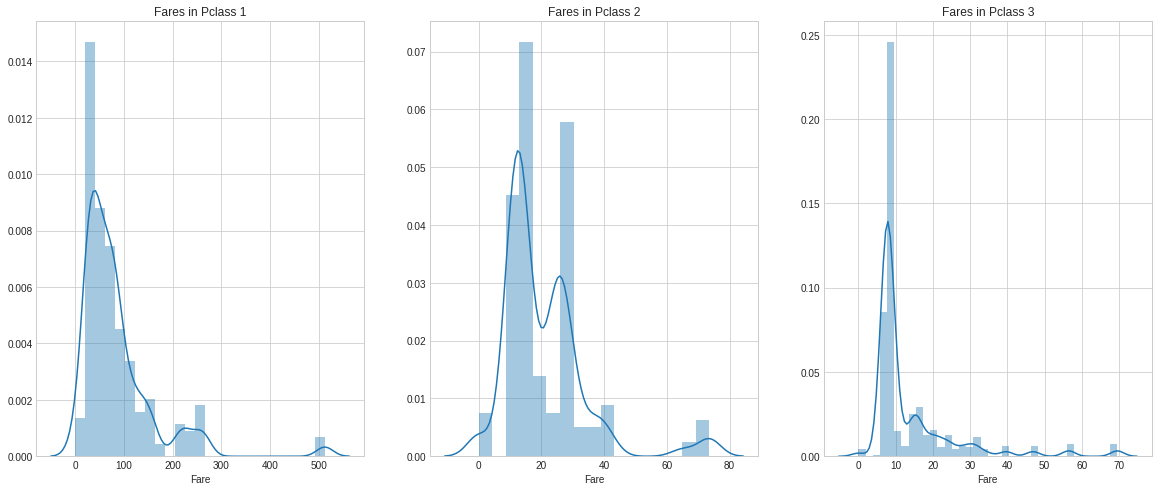

In [ ]:
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.distplot(train[train['Pclass']==1].Fare,ax=ax[0])
ax[0].set_title('Fares in Pclass 1')
sns.distplot(train[train['Pclass']==2].Fare,ax=ax[1])
ax[1].set_title('Fares in Pclass 2')
sns.distplot(train[train['Pclass']==3].Fare,ax=ax[2])
ax[2].set_title('Fares in Pclass 3')
plt.show()

* Pclass1의 승객 요금에는 큰 분포가있는 것으로 보이며이 분포는 표준이 감소함에 따라 계속 감소합니다. 이것은 또한 연속적이므로 비닝을 사용하여 불연속 값으로 변환 할 수 있습니다.

* 추후 좀 변경하기로 하고 일단 새 파일에 옮겨 놓습니다.

In [ ]:
df_bin['Fare'] = train['Fare']
df_con['Fare'] = train['Fare']

In [ ]:
df_bin.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare
0,0,3,1,1,22.0,1,0,7.2500
1,1,1,3,2,38.0,1,0,71.2833
2,1,3,2,2,26.0,0,0,7.9250
3,1,1,3,2,35.0,1,0,53.1000
4,0,3,1,1,35.0,0,0,8.0500


In [ ]:
df_con.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare
0,0,3,1,1,22.0,1,0,7.2500
1,1,1,3,2,38.0,1,0,71.2833
2,1,3,2,2,26.0,0,0,7.9250
3,1,1,3,2,35.0,1,0,53.1000
4,0,3,1,1,35.0,0,0,8.0500


#### 10. Cabin

#### 11. Embarked

In [ ]:
pd.crosstab([train.Embarked,train.Pclass],[train.Sex,train.Survived],margins=True).style.background_gradient(cmap='summer_r')


* 승선 장소 별로 생존 확률

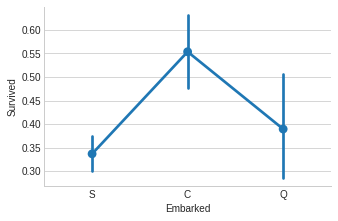

In [ ]:
sns.factorplot('Embarked','Survived',data=train)
fig=plt.gcf()
fig.set_size_inches(5,3)
plt.show()

* 포트 C의 생존 가능성은 0.55 정도이며 S는 가장 낮습니다.

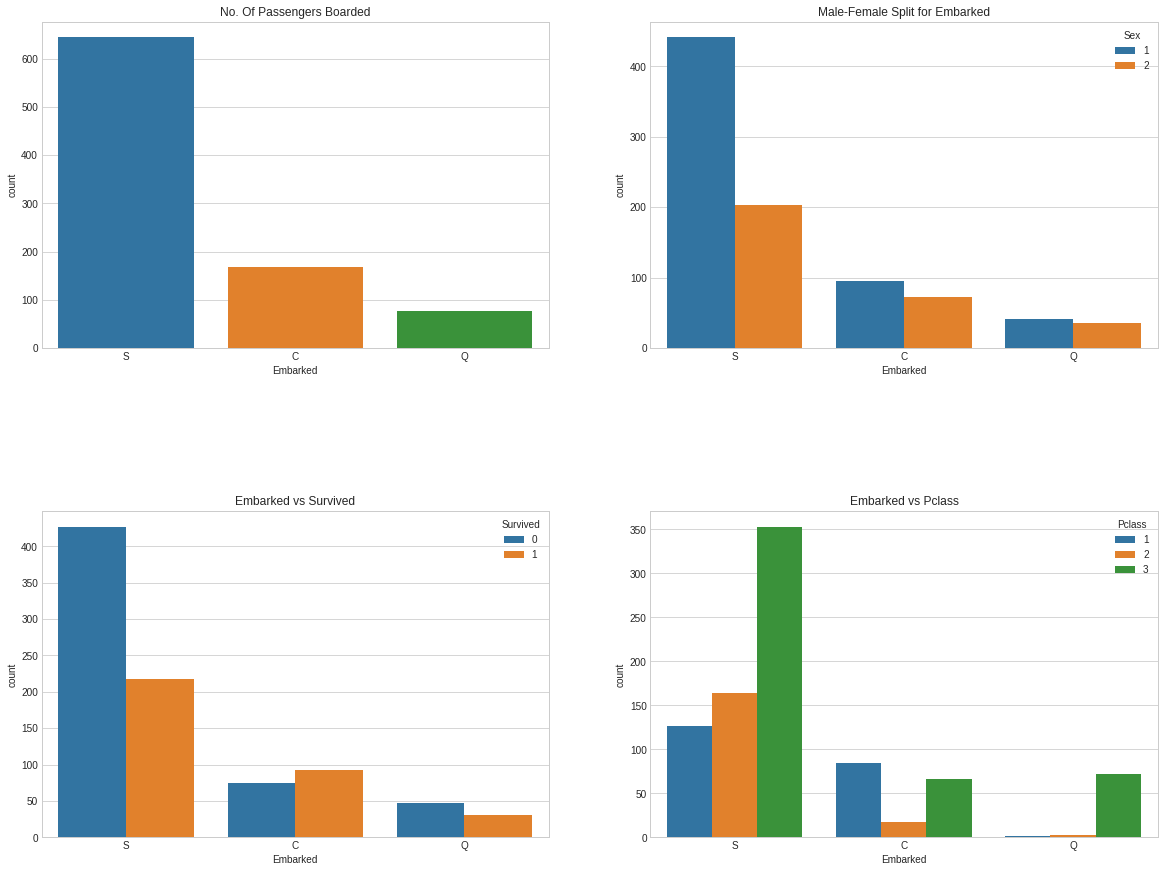

In [ ]:
f,ax=plt.subplots(2,2,figsize=(20,15))
sns.countplot('Embarked',data=train,ax=ax[0,0])
ax[0,0].set_title('No. Of Passengers Boarded')
sns.countplot('Embarked',hue='Sex',data=train,ax=ax[0,1])
ax[0,1].set_title('Male-Female Split for Embarked')
sns.countplot('Embarked',hue='Survived',data=train,ax=ax[1,0])
ax[1,0].set_title('Embarked vs Survived')
sns.countplot('Embarked',hue='Pclass',data=train,ax=ax[1,1])
ax[1,1].set_title('Embarked vs Pclass')
plt.subplots_adjust(wspace=0.2,hspace=0.5)
plt.show()

* 관찰 :
1) S에서 탑승 최대. 대다수는 Pclass3

2) C의 승객들은 많은 비율이 살아남아 운이 좋았습니다. 그 이유는 Pclass1 및 Pclass2 승객이 많아서

3) Embark S는 대부분의 부자들이 탑승한 항구지만 생존 가능성은 낮습니다. Pclass3의 승객도 많았습니다.

4) 포트 Q는 승객의 거의 95 %가 Pclass3

* 전체 내용

* 여성 생존률이 높다
* 객실 클래스가 좋을 수록 생존
* 아이들 생존률이 높은 반면에 젊은 남자들 사망
* 별로 상관없을 것이라 생각했던 탑승지가 중요
* 1-2 명의 형제 자매, 배우자 또는 1-3 명의 부모님이 혼자 있거나 대가족과 함께 여행하는 것보다 생존 확률이 더 높습니다.